In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import numpy as np


In [13]:
# Configuration
DATA_ROOT_DIR = '../full_log/gym/cheetah/vision'  # Path to the data folder outside this notebook
# FOLDER_PATHS = ['cls/0.05/s0_nr','cls/0.1/s0_nr','cls/0.5/s0_nr','cls/1.0/s0_nr']  # Specify folder paths relative to DATA_ROOT_DIR
FOLDER_PATHS=['vanilla/s2_f2','cls/1.0/s3_im','cls/0.5/s3_im','cls/0.1/s2_f1',
              'cls/0.05/s3_im','cls/0.025/s2_f2']
METRICS_FILE_NAME = 'metrics.jsonl'
FIELD_TO_PLOT = 'train/loss/dyn'
FIELD_NAME = 'Dynamics Loss'
# FIELD_TO_PLOT = 'episode/score'
# FIELD_TO_PLOT = 'epstats/score'
# FIELD_NAME = 'Evaluation Score'



In [14]:
# a=FOLDER_PATHS[0]
ks = ['k=' + path.split('/')[1] for path in FOLDER_PATHS]
ks[0] = 'k=0'

In [15]:
# Function to load metrics from JSONL files
def load_metrics_from_jsonl(file_path, field):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            entry = json.loads(line)
            if field in entry:
                data.append({
                    'step': entry['step'],
                    field: entry[field]
                })
    return pd.DataFrame(data)

# Initialize a DataFrame to hold all metrics
all_metrics = pd.DataFrame()


In [16]:
# Search for specified folder paths and load metrics
for folder_path in FOLDER_PATHS:
    full_folder_path = os.path.join(DATA_ROOT_DIR, folder_path)
    metrics_file_path = os.path.join(full_folder_path, METRICS_FILE_NAME)
    
    if os.path.exists(metrics_file_path):
        print(f"Loading metrics from: {metrics_file_path}")
        metrics_df = load_metrics_from_jsonl(metrics_file_path, FIELD_TO_PLOT)
        metrics_df['folder'] = folder_path  # Add a column for the folder path
        all_metrics = pd.concat([all_metrics, metrics_df], ignore_index=True)
    else:
        print(f"Metrics file not found: {metrics_file_path}")


Loading metrics from: ../full_log/gym/cheetah/vision/vanilla/s2_f2/metrics.jsonl
Loading metrics from: ../full_log/gym/cheetah/vision/cls/1.0/s3_im/metrics.jsonl
Loading metrics from: ../full_log/gym/cheetah/vision/cls/0.5/s3_im/metrics.jsonl
Loading metrics from: ../full_log/gym/cheetah/vision/cls/0.1/s2_f1/metrics.jsonl
Loading metrics from: ../full_log/gym/cheetah/vision/cls/0.05/s3_im/metrics.jsonl
Loading metrics from: ../full_log/gym/cheetah/vision/cls/0.025/s2_f2/metrics.jsonl


/tmp/ipykernel_119480/4232733092.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_metrics['legend_label'] = filtered_metrics['folder'].map(folder_to_ks)


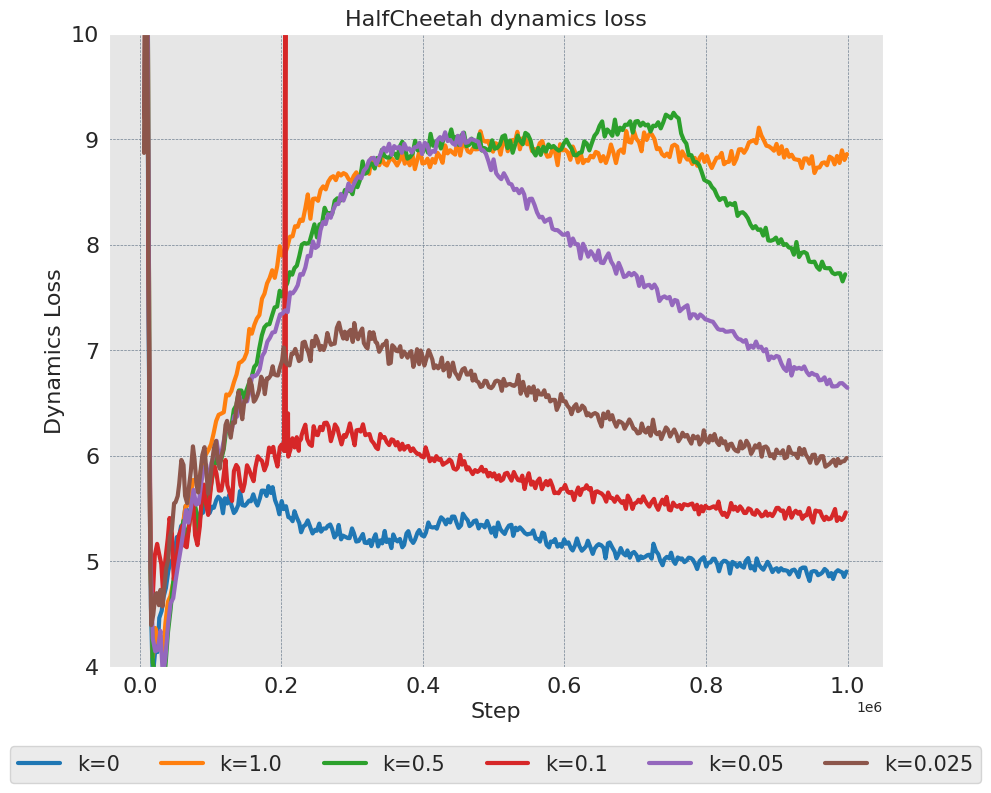

In [21]:
# Sample colors from a perceptually uniform colormap (e.g., 'magma')
# cmap = matplotlib.cm.get_cmap('magma')
# colors = [cmap(i) for i in np.linspace(0, 1, 6)]
# light_green = matplotlib.colors.to_rgba("green")
# colors[0] = light_green  # Replace the first color with light green
# color_idxs = [0, 1, 3, 4]
# colors = [colors[i] for i in color_idxs]

# Filter the data to include only steps <= 1e6
filtered_metrics = all_metrics[all_metrics['step'] <= 1e6]
# filtered_metrics = all_metrics
sns.set_style("darkgrid", {"axes.facecolor": ".9", 'grid.linestyle': '--', 'grid.color': 'slategrey'})

if not filtered_metrics.empty:
    # Map folder paths to ks values for the legend
    folder_to_ks = dict(zip(FOLDER_PATHS, ks))
    filtered_metrics['legend_label'] = filtered_metrics['folder'].map(folder_to_ks)

    plt.figure(figsize=(10, 8))
    ax = sns.lineplot(
        data=filtered_metrics,
        x='step',
        y=FIELD_TO_PLOT,
        hue='legend_label',  # Use ks values as legend labels
        marker='',
        linewidth=3,
        # palette=colors,
    )
    plt.title(f'HalfCheetah {FIELD_NAME.lower()}', fontsize=16)
    plt.xlabel('Step', fontsize=16)
    plt.ylabel(FIELD_NAME, fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    # plt.ylim(1.6, 2.4)
    plt.ylim(4,10)
    plt.legend(fontsize=15, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(ks))
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No metrics data found.")

In [ ]:
blue, orange, green, red